In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, make_scorer, f1_score

# Exploratory Data Analysis

I will perform exploratory data analysis in order to:

- Understand the data and the problem space;

- Identify and address or clean any issues; and

- Construct any additional features that might be useful during modelling.

## target.csv

In [2]:
target_df = pd.read_csv('target.csv')

# Print the shape of target_df
target_df.shape

(10000, 2)

In [3]:
# Check that there are no duplicate values of customer_id
target_df['customer_id'].is_unique

True

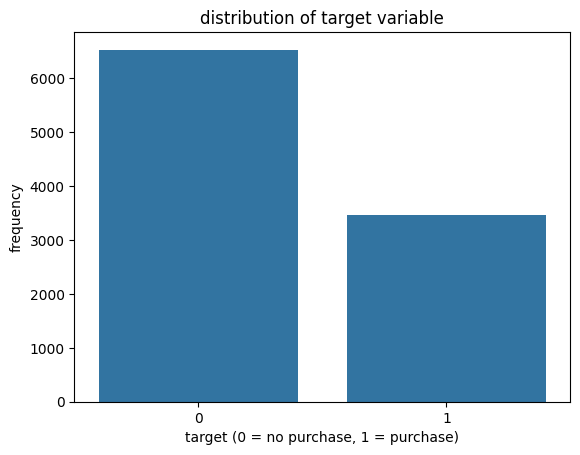

In [4]:
# Visualise the distribution of the target variable
sns.countplot(data=target_df, x='target')
plt.title('distribution of target variable')
plt.xlabel('target (0 = no purchase, 1 = purchase)')
plt.ylabel('frequency')
plt.show()

**NOTE:** There is a class imbalance. The number of customers who made a purchase within the ‘Home’ category within 28 days after the snapshot date is approximately half of those who did not. This will be important when it comes to training and evaluating the model.

## customer_sales.csv

In [5]:
customer_sales_df = pd.read_csv('customer_sales.csv')

# Print the shape of customer_sales_df
customer_sales_df.shape

(10100, 27)

In [6]:
# Check if there are any duplicate rows in customer_sales_df
customer_sales_df.duplicated().any()

True

In [7]:
# Drop any duplicate rows in customer_sales_df
customer_sales_df = customer_sales_df.drop_duplicates()

In [8]:
# Print the shape of customer_sales_df
customer_sales_df.shape

(10000, 27)

In [9]:
# Check that there are no duplicate values of customer_id
customer_sales_df['customer_id'].is_unique

True

The number of rows in $\texttt{customer\_sales\_df}$ now matches the number of rows in $\texttt{target\_df}$, showing that it contains data for all values of $\texttt{customer\_id}$.

Before proceeding, it is worth having a closer look at the columns in $\texttt{customer\_sales\_df}$.

In [10]:
customer_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10099
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          10000 non-null  int64  
 1   spend_cat_home                       10000 non-null  float64
 2   spend_cat_garden                     10000 non-null  float64
 3   spend_cat_sports                     10000 non-null  float64
 4   spend_cat_clothing                   10000 non-null  float64
 5   spend_cat_gifts                      10000 non-null  float64
 6   spend_cat_beauty                     10000 non-null  float64
 7   spend_cat_shoes                      10000 non-null  float64
 8   spend_cat_garden_accessories         10000 non-null  float64
 9   transactions_cat_home                10000 non-null  float64
 10  transactions_cat_garden              10000 non-null  float64
 11  transactions_cat_clothing        

**NOTE:** The last purchase date columns contain null values.

### Logic Checks

The brief states that:

- $\texttt{total\_spend}$ is the total spend within all the categories;

- $\texttt{total\_transactions}$ is the total number of transactions within all the categories; and

- $\texttt{last\_purchase\_date\_all}$ is the date of the latest purchase across all the categories before the snapshot date.

I will calculate each of these columns to ensure that they are accurate.

In [11]:
# total_spend
spend_columns = [
    'spend_cat_home', 'spend_cat_garden',
    'spend_cat_sports', 'spend_cat_clothing',
    'spend_cat_gifts', 'spend_cat_beauty',
    'spend_cat_shoes', 'spend_cat_garden_accessories'
]
customer_sales_df['calculated_total_spend'] = customer_sales_df[spend_columns].sum(axis=1).round(2)

# Compare total_spend with calculated_total_spend
(customer_sales_df['calculated_total_spend'] - customer_sales_df['total_spend']).round(2).value_counts()

 0.00         6105
 0.01         1804
-0.01         1788
 0.02          155
-0.02          145
 0.03            2
 399702.22       1
Name: count, dtype: int64

Other than one outlier, $\texttt{total\_spend}$ and $\texttt{calculated\_total\_spend}$ are similar but not exactly the same.

**ASSUMPTION:** I will assume that the category spend columns are correct, so will use $\texttt{calculated\_total\_spend}$.

I will now examine the outlier.

In [12]:
customer_sales_df[
    (customer_sales_df['calculated_total_spend'] - customer_sales_df['total_spend']).round(2) == 399702.22
]

,customer_id,spend_cat_home,spend_cat_garden,spend_cat_sports,spend_cat_clothing,spend_cat_gifts,spend_cat_beauty,spend_cat_shoes,spend_cat_garden_accessories,transactions_cat_home,...,last_purchase_date_garden,last_purchase_date_clothing,last_purchase_date_gifts,last_purchase_date_sports,last_purchase_date_beauty,last_purchase_date_shoes,total_spend,total_transactions,last_purchase_date_all,calculated_total_spend
7994,17894,99999.0,99999.0,0.0,0.0,0.0,99999.0,99999.0,0.0,99999.0,...,NaN,NaN,NaN,NaN,NaN,NaN,293.78,0.0,NaN,399996.0


There is clearly an issue with the data in many of the columns for $\texttt{customer\_id}=17894$. I will therefore drop this row.

In [13]:
customer_sales_df.drop(customer_sales_df[customer_sales_df['customer_id'] == 17894].index, inplace=True)

In [14]:
# total_transactions
transactions_columns = [
    'transactions_cat_home', 'transactions_cat_garden',
    'transactions_cat_sports', 'transactions_cat_clothing',
    'transactions_cat_gifts', 'transactions_cat_beauty',
    'transactions_cat_shoes', 'transactions_cat_garden_accessories'
]
customer_sales_df['calculated_total_transactions'] = customer_sales_df[transactions_columns].sum(axis=1)

# Compare total_transactions with calculated_total_transactions
(customer_sales_df['calculated_total_transactions'] - customer_sales_df['total_transactions']).value_counts()

0.0    9999
Name: count, dtype: int64

$\texttt{total\_transactions}$ and $\texttt{calculated\_total\_transactions}$ are exactly the same.

In [15]:
# last_purchase_date_all
last_purchase_date_columns = [
    'last_purchase_date_home', 'last_purchase_date_garden',
    'last_purchase_date_sports', 'last_purchase_date_clothing',
    'last_purchase_date_gifts', 'last_purchase_date_beauty', 
    'last_purchase_date_shoes'
]

# Convert the last purchase date columns to datetime64[ns]
customer_sales_df[last_purchase_date_columns] = customer_sales_df[last_purchase_date_columns].apply(pd.to_datetime)
customer_sales_df['last_purchase_date_all'] = customer_sales_df['last_purchase_date_all'].apply(pd.to_datetime)

**NOTE:** Contrary to the brief, from visual inspection of the first few rows of $\texttt{customer\_sales\_df}$, it seems that the $\texttt{last\_purchase\_date\_all}$ column is in fact the date of the *earliest* purchase across all the categories before the snapshot date.

In [16]:
# Check that last_purchase_date_all is in fact the earliest date across all last purchase date columns
(customer_sales_df['last_purchase_date_all'] - customer_sales_df[last_purchase_date_columns].min(axis=1)).value_counts()

0 days    8513
Name: count, dtype: int64

This confirms my hypothesis. It is therefore necessary to calculate this column correctly.

In [17]:
customer_sales_df['calculated_last_purchase_date_all'] = customer_sales_df[last_purchase_date_columns].max(axis=1)

**NOTE:** Contrary to the brief, the $\texttt{last\_purchase\_date\_garden\_accessories}$ column does not exist in $\texttt{customer\_sales.csv}$. Therefore, $\texttt{calculated\_last\_purchase\_date\_all}$ is still potentially inaccurate as purchases in the 'Garden Accessories' category are not taken into account.

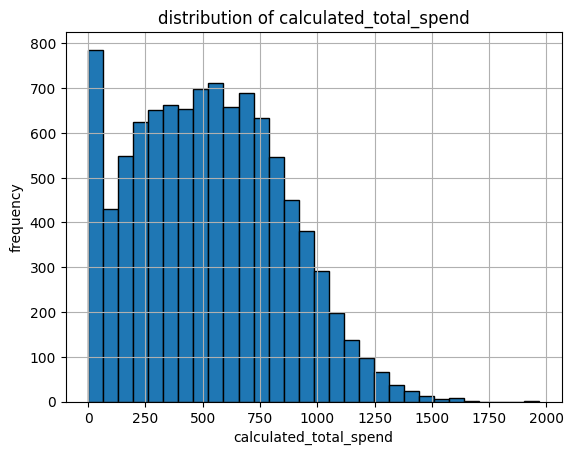

In [18]:
# Visualise the distribution of calculated_total_spend
customer_sales_df['calculated_total_spend'].hist(bins=30, edgecolor='black')
plt.title('distribution of calculated_total_spend')
plt.xlabel('calculated_total_spend')
plt.ylabel('frequency')
plt.show()

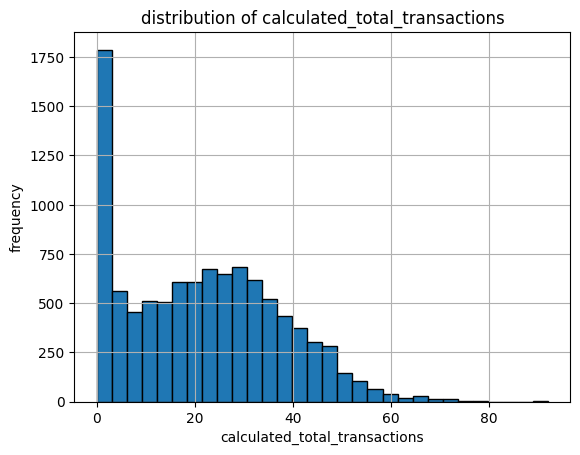

In [19]:
# Visualise the distribution of calculated_total_transactions
customer_sales_df['calculated_total_transactions'].hist(bins=30, edgecolor='black')
plt.title('distribution of calculated_total_transactions')
plt.xlabel('calculated_total_transactions')
plt.ylabel('frequency')
plt.show()

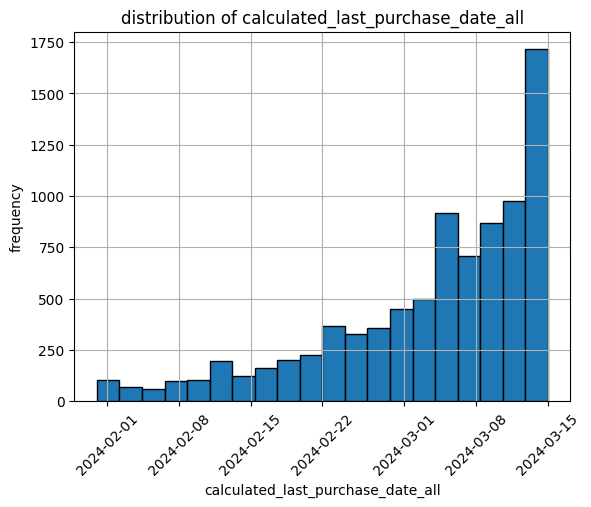

In [20]:
# Visualise the distribution of calculated_last_purchase_date_all
customer_sales_df['calculated_last_purchase_date_all'].hist(bins=20, edgecolor='black')
plt.title('distribution of calculated_last_purchase_date_all')
plt.xlabel('calculated_last_purchase_date_all')
plt.ylabel('frequency')
plt.xticks(rotation=45)
plt.show()

A date is quite difficult to work with when training a model, so I will create a feature that captures the number of days between the date of the latest purchase in the ‘Home’ category and the snapshot date.

In [21]:
reference_date = pd.Timestamp('2024-03-16')
customer_sales_df['days_since_last_home_purchase'] = (reference_date - customer_sales_df['last_purchase_date_home']).dt.days.astype(float)

### Missing Data

From visual inspection, the following inconsistencies are apparent:

1. There some rows where $\texttt{calculated\_total\_spend} > 0$ but $\texttt{calculated\_total\_transactions} = 0$.

In [22]:
customer_sales_df[
    (customer_sales_df['calculated_total_spend'] > 0) &
    (customer_sales_df['calculated_total_transactions'] == 0)
].head()

,customer_id,spend_cat_home,spend_cat_garden,spend_cat_sports,spend_cat_clothing,spend_cat_gifts,spend_cat_beauty,spend_cat_shoes,spend_cat_garden_accessories,transactions_cat_home,...,last_purchase_date_sports,last_purchase_date_beauty,last_purchase_date_shoes,total_spend,total_transactions,last_purchase_date_all,calculated_total_spend,calculated_total_transactions,calculated_last_purchase_date_all,days_since_last_home_purchase
0,10000,0.0,0.0,0.0,0.0,0.0,0.0,225.68,0.0,0.0,...,NaT,NaT,NaT,225.68,0.0,NaT,225.68,0.0,NaT,NaN
5,10005,0.0,0.0,0.0,0.0,0.0,0.0,278.17,0.0,0.0,...,NaT,NaT,NaT,278.17,0.0,NaT,278.17,0.0,NaT,NaN
9,10009,0.0,0.0,0.0,0.0,0.0,0.0,253.88,0.0,0.0,...,NaT,NaT,NaT,253.88,0.0,NaT,253.88,0.0,NaT,NaN
13,10013,0.0,0.0,0.0,0.0,0.0,0.0,257.71,0.0,0.0,...,NaT,NaT,NaT,257.71,0.0,NaT,257.71,0.0,NaT,NaN
19,10019,0.0,0.0,0.0,0.0,0.0,0.0,249.95,0.0,0.0,...,NaT,NaT,NaT,249.95,0.0,NaT,249.95,0.0,NaT,NaN


2. There some rows where $\texttt{calculated\_total\_spend} > 0$ but $\texttt{calculated\_last\_purchase\_date\_all}$ is null.

In [23]:
customer_sales_df[
    (customer_sales_df['calculated_total_spend'] > 0) &
    (customer_sales_df['calculated_last_purchase_date_all'].isnull())
].head()

,customer_id,spend_cat_home,spend_cat_garden,spend_cat_sports,spend_cat_clothing,spend_cat_gifts,spend_cat_beauty,spend_cat_shoes,spend_cat_garden_accessories,transactions_cat_home,...,last_purchase_date_sports,last_purchase_date_beauty,last_purchase_date_shoes,total_spend,total_transactions,last_purchase_date_all,calculated_total_spend,calculated_total_transactions,calculated_last_purchase_date_all,days_since_last_home_purchase
0,10000,0.0,0.0,0.0,0.0,0.0,0.0,225.68,0.0,0.0,...,NaT,NaT,NaT,225.68,0.0,NaT,225.68,0.0,NaT,NaN
5,10005,0.0,0.0,0.0,0.0,0.0,0.0,278.17,0.0,0.0,...,NaT,NaT,NaT,278.17,0.0,NaT,278.17,0.0,NaT,NaN
9,10009,0.0,0.0,0.0,0.0,0.0,0.0,253.88,0.0,0.0,...,NaT,NaT,NaT,253.88,0.0,NaT,253.88,0.0,NaT,NaN
13,10013,0.0,0.0,0.0,0.0,0.0,0.0,257.71,0.0,0.0,...,NaT,NaT,NaT,257.71,0.0,NaT,257.71,0.0,NaT,NaN
19,10019,0.0,0.0,0.0,0.0,0.0,0.0,249.95,0.0,0.0,...,NaT,NaT,NaT,249.95,0.0,NaT,249.95,0.0,NaT,NaN


Interestingly, both of the above inconsistencies highlight the same rows: rows where the $\texttt{spend\_cat\_shoes}>0$ but all other spend, transactions and last purchase date columns are $0$ / null.

**ASSUMPTION:** The $\texttt{transactions\_cat\_shoes}$ and $\texttt{last\_purchase\_date\_shoes}$ columns (and by extension the $\texttt{calculated\_total\_transactions}$ and $\texttt{calculated\_last\_purchase\_date\_all}$ columns) are inaccurate.

I am aware that $\texttt{transactions\_cat\_shoes}$ and $\texttt{last\_purchase\_date\_shoes}$ contain realistic values in other rows of $\texttt{customer\_sales\_df}$, so I could instead have assumed that just these $848$ rows are inaccurate.

In [24]:
# Define combined_df to store joined data
combined_df = pd.merge(target_df, customer_sales_df, on='customer_id', how='inner')

## additional.csv

In [25]:
additional_df = pd.read_csv('additional.csv')

# Print the shape of additional_df
additional_df.shape

(10000, 7)

In [26]:
# Check if there are any duplicate rows in additional_df
additional_df.duplicated().any()

False

In [27]:
# Check that there are no duplicate values of customer_id
additional_df['customer_id'].is_unique

True

The number of rows in $\texttt{additional\_df}$ matches the number of rows in $\texttt{target\_df}$, showing that it contains data for all values of $\texttt{customer\_id}$.

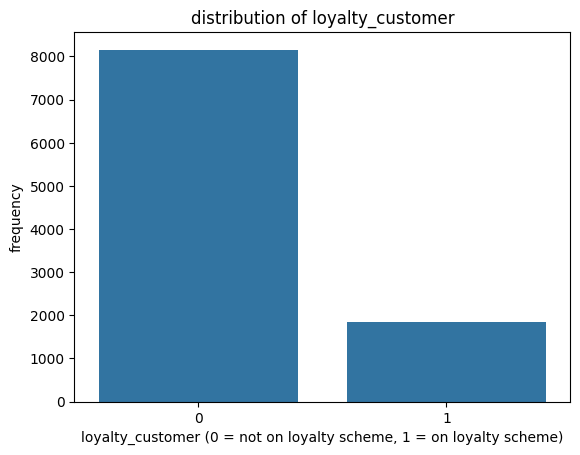

In [28]:
# Visualise the distribution of loyalty_customer
sns.countplot(data=additional_df, x='loyalty_customer')
plt.title('distribution of loyalty_customer')
plt.xlabel('loyalty_customer (0 = not on loyalty scheme, 1 = on loyalty scheme)')
plt.ylabel('frequency')
plt.show()

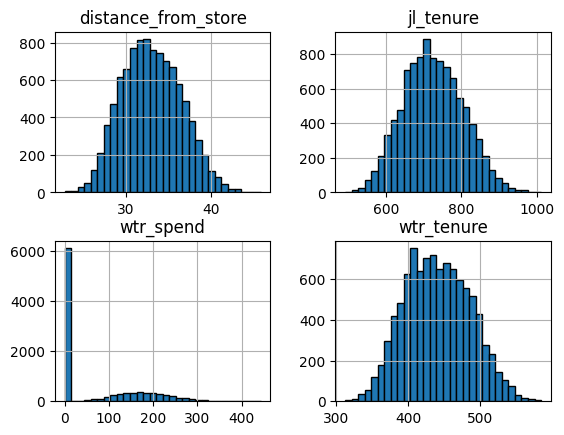

In [29]:
# Visualise the distributions of the remaining numerical columns
additional_df[['distance_from_store', 'jl_tenure', 'wtr_spend', 'wtr_tenure']].hist(bins=30, edgecolor='black')
plt.show()

The last column is $\texttt{closest\_store}$. It is interesting to see the distribution of this column broken down by the target variable.

In [30]:
combined_df = pd.merge(combined_df, additional_df, on='customer_id', how='inner')

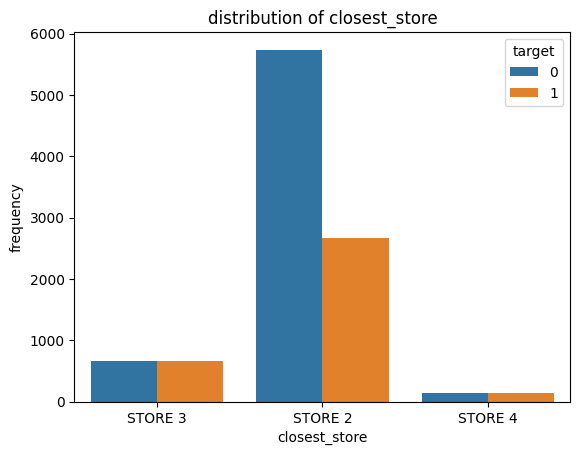

In [31]:
# Visualise the distribution of closest_store, broken down by the target variable
sns.countplot(data=combined_df, x='closest_store', hue='target')
plt.title('distribution of closest_store')
plt.xlabel('closest_store')
plt.ylabel('frequency')
plt.show()

Customers were much less likely to make a purchase within the ‘Home’ category within 28 days after the snapshot date if their closest John Lewis store was STORE 2. The data in this column is quite difficult to work with when training a model, so I will create a binary feature indicating if a customer's closest John Lewis store is STORE 2.

In [32]:
combined_df['store_2'] = combined_df['closest_store'].apply(lambda x: 1 if x == 'STORE 2' else 0)

## browsing.csv

In [33]:
browsing_df = pd.read_csv('browsing.csv')

The path of the page contains two key pieces of information: the category and the product. I will create a dataframe that contains the number of pages viewed in the 'Home' category and all categories for each customer.

In [34]:
# Extract the category from the path
browsing_df['category'] = browsing_df['page_view'].str.extract(r'category_(\w+)/')

In [35]:
# Define cust_browsing_df to store the required data
cust_browsing_df = (
    browsing_df.groupby(['customer_id', 'category'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
cust_browsing_df.columns = ['customer_id'] + [f'{cat}_views' for cat in cust_browsing_df.columns[1:]]

cust_browsing_df.head()

,customer_id,beauty_views,clothing_views,garden_views,gifts_views,home_views
0,10000,0,1,3,2,3
1,10001,0,0,4,0,3
2,10002,0,1,6,0,8
3,10003,0,1,1,0,0
4,10004,1,2,3,1,5


**NOTE:** Some categories are missing. Specifically, sports, shoes and garden accessories.

In [36]:
# Create a total_views column
view_columns = ['beauty_views', 'clothing_views', 'garden_views', 'gifts_views', 'home_views']
cust_browsing_df['total_views'] = cust_browsing_df[view_columns].sum(axis=1)

# Drop columns that are not required
cust_browsing_df = cust_browsing_df.drop(['beauty_views', 'clothing_views', 'garden_views', 'gifts_views'], axis=1)

In [37]:
# Print the shape of cust_browsing_df
cust_browsing_df.shape

(8365, 3)

Some customers are missing from $\texttt{cust\_browsing\_df}$.

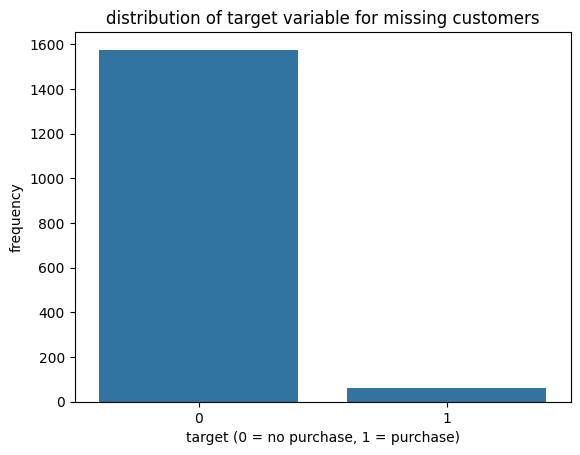

In [38]:
# Visualise the distribution of the target variable for customers who are missing from cust_browsing_df
missing_customers = set(target_df['customer_id']) - set(browsing_df['customer_id'])
missing_customers_data = target_df[target_df['customer_id'].isin(missing_customers)]

sns.countplot(x='target', data=missing_customers_data)
plt.title('distribution of target variable for missing customers')
plt.xlabel('target (0 = no purchase, 1 = purchase)')
plt.ylabel('frequency')
plt.show()

The class imbalance is significantly more pronounced here.

**ASSUMPTION:** If a customer is missing from $\texttt{browsing.csv}$, it is because they did not visit any pages on the John Lewis website before the snapshot date.

It is therefore appropriate to set $\texttt{home\_views}$ and $\texttt{total\_views}$ for these customers to $0$.

In [39]:
combined_df = pd.merge(combined_df, cust_browsing_df, on='customer_id', how='left')
combined_df[['home_views', 'total_views']] = combined_df[['total_views', 'home_views']].fillna(0)

## demographics.csv

In [40]:
demographics_df = pd.read_csv('demographics.csv')

In [41]:
# Check that all column values are consistent with the brief
demographics_df[
    ~demographics_df['affluence'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]) |
    ~demographics_df['hh_size'].isin([1.0, 2.0, 3.0, 4.0]) |
    ~demographics_df['customer_segment'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
]

,customer_id,affluence,hh_size,customer_segment
6385,17894,99999.0,99999.0,99999.0


There is clearly an issue with the data in all of the columns for $\texttt{customer\_id}=17894$. I will therefore drop this row.

In [42]:
demographics_df.drop(demographics_df[demographics_df['customer_id'] == 17894].index, inplace=True)

In [43]:
# Print the shape of demographics_df
demographics_df.shape

(8090, 4)

In [44]:
# Check that there are no duplicate values of customer_id
demographics_df['customer_id'].is_unique

True

There are approximately $2000$ customers missing from $\texttt{demographics\_df}$.

It is worth checking if missing from $\texttt{demographics\_df}$ is significant in terms of the target variable.

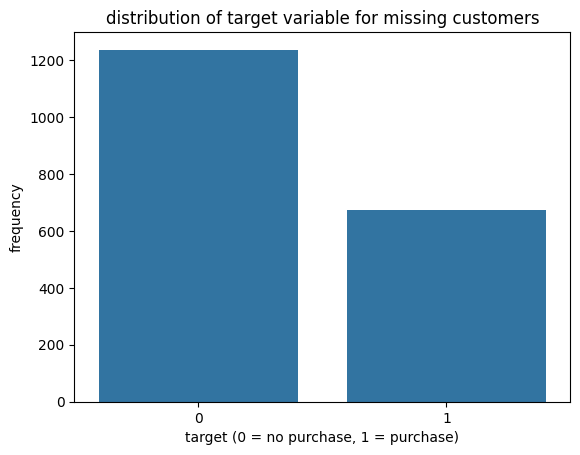

In [45]:
# Visualise the distribution of the target variable for customers who are missing from demographics_df
missing_customers = set(target_df['customer_id']) - set(demographics_df['customer_id'])
missing_customers_data = target_df[target_df['customer_id'].isin(missing_customers)]

sns.countplot(x='target', data=missing_customers_data)
plt.title('distribution of target variable for missing customers')
plt.xlabel('target (0 = no purchase, 1 = purchase)')
plt.ylabel('frequency')
plt.show()

The class imbalance is similar to the overall case. I do not want to train a model on data that is not available for all customers, so I will not use this data.

# Feature Selection

Based on my exploratory data analysis, I have made the following key assumptions:

- The category spend columns are correct, so I will use $\texttt{calculated\_total\_spend}$ as opposed to $\texttt{total\_spend}$;

- The $\texttt{transactions\_cat\_shoes}$ and $\texttt{last\_purchase\_date\_shoes}$ columns (and by extension the $\texttt{calculated\_total\_transactions}$ and $\texttt{calculated\_last\_purchase\_date\_all}$ columns) are inaccurate, so I will not use them.

Finally, so that all models can be used, I will not use the $\texttt{days\_since\_last\_home\_purchase}$ feature that I created as it contains null values.

In [46]:
feature_variables = ['spend_cat_home',
                     'calculated_total_spend',
                     'transactions_cat_home',
                     'loyalty_customer',
                     'store_2',
                     'distance_from_store',
                     'jl_tenure',
                     'wtr_spend',
                     'wtr_tenure',
                     'home_views',
                     'total_views']

# Model Selection & Tuning

In [47]:
X = combined_df[feature_variables]
y = combined_df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

This is a classification problem. I will use a random forest classifier for the following reasons.

- **Flexibility:** Random forest can work with both numeric and binary features without requiring extensive preprocessing, as it is not sensitive to the scale or distribution of the features.

- **Interpretability:** Random forest inherently calculates feature importance, which could help us understand which variables contribute most to the classification.

- **Robustness:** By averaging predictions from multiple decision trees, random forest reduces overfitting compared to a single decision tree, providing better generalisation on unseen data.

In [48]:
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced')

# Train the model
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1296
           1       0.74      0.66      0.70       704

    accuracy                           0.80      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.79      0.80      0.80      2000



I will tune one of the hyperparameters. Specifically, $\texttt{max\_depth}$, which is the maximum depth of the tree. Before doing so, I must decide on the metric to use.

**Overall accuracy** measures the proportion of correct predictions out of all predictions. This gives an overall sense of how well the model performs. However, it can be misleading in imbalanced datasets where one class dominates.

**Precision** measures the proportion of true positive predictions out of all predicted positives, indicating the accuracy of positive predictions. It is useful when minimising false positives is important, such as avoiding irrelevant / wasteful communications.

**Recall** measures the proportion of true positive predictions out of all actual positives, indicating the model’s ability to identify positive instances. It is useful when minimising false negatives is important, such as ensuring potential buyers are not missed.

**F1-score** is the harmonic mean of precision and recall, providing a balanced measure of the model’s accuracy in positive predictions and coverage. It is useful when there is a need to balance false positives and false negatives.

For this task, where the goal is to predict the likelihood of a customer purchasing within the ‘Home’ category, F1-score is the best metric to evaluate the model. It balances precision and recall, ensuring the model is effective in both identifying potential buyers and avoiding irrelevant communications.

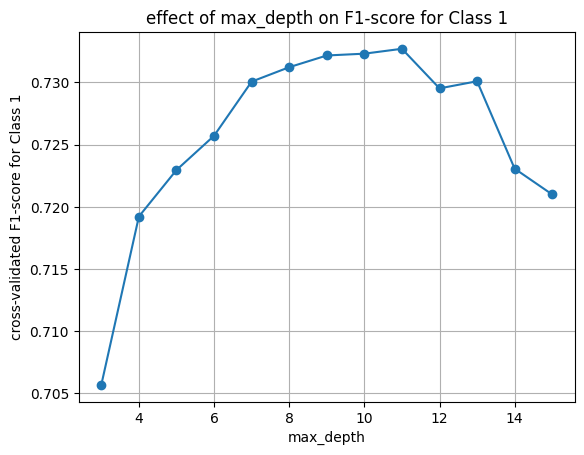

In [49]:
# Define a custom scorer for F1-score of class 1
f1_class_1_scorer = make_scorer(f1_score, pos_label=1)

# Define a range of max_depth
max_depths = np.arange(3, 16)

# Store the mean F1-scores for class 1
mean_f1_scores = []

for max_depth in max_depths:
    rf = RandomForestClassifier(n_estimators=500, max_depth=max_depth, class_weight='balanced')
    # Perform 10-fold cross-validation
    scores = cross_val_score(rf, X_train, y_train, cv=10, scoring=f1_class_1_scorer)
    mean_f1_scores.append(scores.mean())

# Plot the results
plt.figure()
plt.plot(max_depths, mean_f1_scores, marker='o', linestyle='-')
plt.xlabel('max_depth')
plt.ylabel('cross-validated F1-score for Class 1')
plt.title('effect of max_depth on F1-score for Class 1')
plt.grid()
plt.show()

In [52]:
# Train rf with the optimal value of max_depth
rf = RandomForestClassifier(n_estimators=500, max_depth=11, class_weight='balanced')

# Train the model
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1296
           1       0.69      0.76      0.72       704

    accuracy                           0.79      2000
   macro avg       0.77      0.79      0.78      2000
weighted avg       0.80      0.79      0.79      2000



In [53]:
# Get the predicted probabilities
y_probs = rf.predict_proba(X_test)

# To extract the likelihood of the test customers shopping in the ‘Home’ category:
y_probs[:, 1]

array([0.00244762, 0.33607112, 0.62647686, ..., 0.02151403, 0.344967  ,
       0.00287296])

# Model Evaluation

For class 0 (customers who did not purchase in the 'Home' category), the model's performance is as follows:

Precision for class 0 is 0.86, indicating that when the model predicts a customer will not buy, it is correct 86% of the time. Recall for class 0 is 0.81, meaning that 81% of the actual non-buyers are correctly identified by the model. F1-score for class 0 is 0.83, balancing precision and recall for non-buyers, showing a strong overall performance for this class.

For class 1 (customers who made a purchase in the 'Home' category), the model's performance is as follows:

Precision for class 1 is 0.69, indicating that when the model predicts a customer will buy, it is correct 69% of the time. Recall for class 1 is 0.76, meaning the model captures 76% of the actual buyers. F1-score for class 1 is 0.72, balancing the precision and recall for buyers, showing a moderate performance for this class.

The overall accuracy of the model is 0.79, meaning 79% of the predictions across both classes were correct.

The model performs well in identifying non-buyers (class 0) with high precision, but it can be further improved in predicting buyers (class 1), where both precision and F1-score are lower. The F1-score suggests that the model balances recall and precision fairly well, but there is room for improvement in classifying potential buyers without misclassifying too many non-buyers.

# Future Work

**Potential improvements**

- Tune other hyperparameters, such as $\texttt{max\_features}$, which is the number of features to consider when looking for the best split.

- Experiment with the inclusion of other features in the model, such as spend in other categories and $\texttt{days\_since\_last\_home\_purchase}$ (which will require null values to be filled).

- Experiment with the inclusion of a feature that captures the number of product pages viewed in the 'Home' category and all categories for each customer.

**Further ideas**

- Test other models, such as logistic regression and k-nearest neighbours.

**Areas that would warrant further investigation**

- I want to talk to the data owners of $\texttt{browsing.csv}$ and $\texttt{demographics.csv}$ to understand why some values of $\texttt{customer\_id}$ are missing from these files. The reason could impact the appropriate way to use the data in these files.

- I also want to understand why the sports, shoes and garden accessories categories are missing from $\texttt{browsing.csv}$. The reason could impact the appropriate way to use the data in this file.